### Analysis - Paper sec5 Information loss in assembly causes biases in assembly-based taxonomic characterization of metagenomes

#### Titus: misc thoughts on analysis -
- what’s in the notebook is a single accession, one for which you have the assembly. It shows that assembly discards k-mers with known taxonomy (as we already know from chp 3).
- so, this is for one. but it would be good to get some kind of summary across all 84 assemblies. not sure how to do that.
- the points we could make
    - assembly decreases taxonomic signal.
    - assembly is eliminating low-abundance stuff, but some of that low abundance stuff is “good” (can be assigned to a reference genome)
...

#### data & nb on farm at: /home/ctbrown/scratch3/2026-assembly-loss-tax
#### github.com/ctb/2026-assembly-loss-tax/blob/…/trial.ipynb

In [31]:
!pwd

/group/ctbrowngrp4/2025-zyzhao-assemloss/tax


In [32]:
#!/usr/bin/env python3
"""
The notebook workflow:

1) Set paths
2) Load one sample and verify columns
3) Define family aggregation function
4) Loop through all 84 samples
5) Generate:
    - per-sample retention summary
    - family-level retention table
6) Plot assembly loss patterns
"""

'\nThe notebook workflow:\n\n1) Set paths\n2) Load one sample and verify columns\n3) Define family aggregation function\n4) Loop through all 84 samples\n5) Generate:\n    - per-sample retention summary\n    - family-level retention table\n6) Plot assembly loss patterns\n'

In [33]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
import taxburst.checks

In [34]:
# Set path
from pathlib import Path

TRIM_DIR = Path("/home/ctbrown/scratch3/2026-assembly-loss-tax/outputs/trim")
INFLATE_DIR = Path("/home/ctbrown/scratch3/2026-assembly-loss-tax/outputs/inflate")

OUT_DIR = Path("/home/zyzhao/2025-zyzhao-assemloss/tax/outputs")
OUT_DIR.mkdir(exist_ok=True, parents=True)

print(TRIM_DIR)
print(INFLATE_DIR)

/home/ctbrown/scratch3/2026-assembly-loss-tax/outputs/trim
/home/ctbrown/scratch3/2026-assembly-loss-tax/outputs/inflate


In [35]:
# check one file
trim_example = list(TRIM_DIR.glob("*.gather.with-lineages.csv"))[0]

print(trim_example)
df = pd.read_csv(trim_example)
df.head()

/home/ctbrown/scratch3/2026-assembly-loss-tax/outputs/trim/ERR2241845.gather.with-lineages.csv


,intersect_bp,f_orig_query,f_match,f_unique_to_query,f_unique_weighted,average_abund,median_abund,std_abund,filename,name,...,query_abundance,query_containment_ani,match_containment_ani,average_containment_ani,max_containment_ani,potential_false_negative,n_unique_weighted_found,sum_weighted_found,total_weighted_hashes,lineage
0,3389000,0.000833,0.846615,0.000833,0.008108,20.329891,10.0,146.151002,/group/ctbrowngrp5/sourmash-db.new/gtdb-rs226/...,GCF_002251435.1 Prevotella sp. P2-180,...,True,0.795542,0.994643,0.895093,0.994643,False,68898,68898,8497828,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...
1,3337000,0.000820,0.796806,0.000797,0.003281,8.597286,4.0,19.322490,/group/ctbrowngrp5/sourmash-db.new/gtdb-rs226/...,GCA_945982685.1 uncultured Prevotella sp.,...,True,0.795145,0.993615,0.894380,0.993615,False,27881,96779,8497828,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...
2,3000000,0.000737,0.894658,0.000737,0.003613,10.239827,8.0,36.735349,/group/ctbrowngrp5/sourmash-db.new/gtdb-rs226/...,GCA_004552745.1 Bacteroidales bacterium,...,True,0.792419,0.996437,0.894428,0.996437,False,30699,127478,8497828,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...
3,3175000,0.000780,0.867131,0.000735,0.007335,20.852794,18.0,41.310723,/group/ctbrowngrp5/sourmash-db.new/gtdb-rs226/...,GCF_002251245.1 Prevotella sp. P5-92,...,True,0.793870,0.997352,0.895611,0.997352,False,62329,189807,8497828,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...
4,3181000,0.000782,0.834612,0.000722,0.002459,7.115764,6.0,7.741452,/group/ctbrowngrp5/sourmash-db.new/gtdb-rs226/...,GCA_022775105.1 Prevotella sp.,...,True,0.793918,0.996748,0.895333,0.996748,False,20899,210706,8497828,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...


In [36]:
df.columns.tolist()

['intersect_bp',
 'f_orig_query',
 'f_match',
 'f_unique_to_query',
 'f_unique_weighted',
 'average_abund',
 'median_abund',
 'std_abund',
 'filename',
 'name',
 'md5',
 'f_match_orig',
 'unique_intersect_bp',
 'gather_result_rank',
 'remaining_bp',
 'query_filename',
 'query_name',
 'query_md5',
 'query_bp',
 'ksize',
 'moltype',
 'scaled',
 'query_n_hashes',
 'query_abundance',
 'query_containment_ani',
 'match_containment_ani',
 'average_containment_ani',
 'max_containment_ani',
 'potential_false_negative',
 'n_unique_weighted_found',
 'sum_weighted_found',
 'total_weighted_hashes',
 'lineage']

In [37]:
# function to summarize taxonomy
def load_family_counts(filename):
    
    df = pd.read_csv(filename)
    df["family"] = (df["lineage"].fillna("").str.split(";").str[4])
    df = df[(df["family"].notna()) & (df["family"] != "")]

    family_counts = (df.groupby("family")["n_unique_weighted_found"].sum().sort_values(ascending=False))
    return family_counts

In [38]:
# check one sample
trim_file = "/home/ctbrown/scratch3/2026-assembly-loss-tax/outputs/trim/ERR2241845.gather.with-lineages.csv"
family_counts = load_family_counts(trim_file)
family_counts.head(10)

family
f__Bacteroidaceae        1182687
f__Oscillospiraceae       470682
f__UBA932                 357904
f__Lachnospiraceae        331963
f__CAG-138                245035
f__Treponemataceae        238723
f__Muribaculaceae         180530
f__Ruminococcaceae        127175
f__Lactobacillaceae       123151
f__Acutalibacteraceae     115670
Name: n_unique_weighted_found, dtype: int64

In [39]:
# check inspect the total signal
family_counts.sum(), df["n_unique_weighted_found"].sum()
# they should be close (minor differences only if some lineage entries lack family).

(np.int64(4391647), np.int64(4391647))

In [40]:
# compare trim vs inflate
# load the matching inflate file
inflate_file = "/home/ctbrown/scratch3/2026-assembly-loss-tax/outputs/inflate/ERR2241845.gather.with-lineages.csv"
inflate_family_counts = load_family_counts(inflate_file)
inflate_family_counts.head(5)

family
f__Bacteroidaceae      978324
f__Oscillospiraceae    336858
f__UBA932              302395
f__Lachnospiraceae     234408
f__CAG-138             212546
Name: n_unique_weighted_found, dtype: int64

In [41]:
# Then compare:
comparison = pd.concat([family_counts.rename("trim"),inflate_family_counts.rename("inflate")], axis=1).fillna(0)
comparison["retention"] = (comparison["inflate"] /comparison["trim"])
comparison.sort_values("trim",ascending=False).head(5)

,trim,inflate,retention
family,,,
f__Bacteroidaceae,1182687.0,978324.0,0.827204
f__Oscillospiraceae,470682.0,336858.0,0.715681
f__UBA932,357904.0,302395.0,0.844905
f__Lachnospiraceae,331963.0,234408.0,0.706127
f__CAG-138,245035.0,212546.0,0.867411


#### Interpretation of above result:
##### 1) Assembly does not simply remove a fixed fraction of sequence, the retention varies by taxon.
##### 2) Even abundant taxa lose substantial taxonomic signal
- (f__Bacteroidaceae loses 1,182,687−978,324 = 204,363 weighted hashes)

In [42]:
# looking at the low-abundance tail to tests the hypothesis:
# Assembly decreases taxonomic signal and preferentially removes some low-abundance but reference-assignable taxa.

In [43]:
lost_one = comparison[(comparison["trim"] > 0) & (comparison["inflate"] == 0)]
lost_one.sort_values("trim",ascending=False).head(5)

,trim,inflate,retention
family,,,
f__Intestinicryptomonadaceae,381.0,0.0,0.0
f__Cellvibrionaceae,56.0,0.0,0.0
f__UBA1709,41.0,0.0,0.0
f__CALWSW01,35.0,0.0,0.0
f__HGM14224,34.0,0.0,0.0


In [44]:
# How many families are completely lost?
len(lost_one)

695

In [45]:
# What is the abundance distribution of lost families? for families that were:
# - detected in the trimmed reads (trim > 0)
# - completely absent from the assembly-represented signal (inflate == 0)
lost_one["trim"].describe()

count    695.000000
mean       3.391367
std       15.046592
min        1.000000
25%        1.000000
50%        1.000000
75%        3.000000
max      381.000000
Name: trim, dtype: float64

### Interpretation: Most lost families are extremely low abundance
#### The key numbers:
- Median = 1
- 75% percentile = 3
#### Meaning:
- Half of all families lost after assembly had only 1 weighted taxonomic hash in the read-level profile, and 75% had 3 or fewer.
- Assembly preferentially removes low-abundance (weak) but reference-supported biological taxonomic signal.
- for example: 
    - f__Intestinicryptomonadaceae    381
    - f__Cellvibrionaceae              56

In [46]:
# log visualization
np.log10(lost_one["trim"])

family
f__Intestinicryptomonadaceae    2.580925
f__Cellvibrionaceae             1.748188
f__UBA1709                      1.612784
f__CALWSW01                     1.544068
f__HGM14224                     1.531479
                                  ...   
f__Palsa-688                    0.000000
f__Poriferihabitantaceae        0.000000
f__Pluralincolimonadaceae       0.000000
f__Phreatobacteraceae           0.000000
f__40CM-4-68-19                 0.000000
Name: trim, Length: 695, dtype: float64

In [47]:
# define function Loop to summarize lost families for each sample
def compare_sample(sample):

    trim_file = (TRIM_DIR / f"{sample}.gather.with-lineages.csv")
    inflate_file = (INFLATE_DIR /f"{sample}.gather.with-lineages.csv")

    trim = load_family_counts(trim_file)
    inflate = load_family_counts(inflate_file)
    comparison = pd.concat([trim.rename("trim"),inflate.rename("inflate")],axis=1).fillna(0)

    comparison["retention"] = (comparison["inflate"] /comparison["trim"])
    lost = comparison[(comparison["trim"] > 0) & (comparison["inflate"] == 0)]
    retained = comparison[comparison["inflate"] > 0]

    summary = {
        "sample": sample,
        "total_families": len(comparison),
        "lost_families": len(lost),
        "lost_fraction": len(lost) / len(comparison),
        "median_lost_abundance": lost["trim"].median(),
        "mean_lost_abundance": lost["trim"].mean(),
        "max_lost_abundance": lost["trim"].max(),
        "median_retained_abundance": retained["trim"].median()
    }
    return summary, lost, comparison

In [48]:
# check one sample
summary, lost, comparison = compare_sample("ERR2241845")
summary

{'sample': 'ERR2241845',
 'total_families': 1118,
 'lost_families': 695,
 'lost_fraction': 0.6216457960644007,
 'median_lost_abundance': np.float64(1.0),
 'mean_lost_abundance': np.float64(3.39136690647482),
 'max_lost_abundance': np.float64(381.0),
 'median_retained_abundance': np.float64(22.0)}

#### Interperation:
- The original metagenome contained 1118 taxonomic families.
- After assembly, 695 families disappeared (62% loss), about 38% of detected families remained
- Half of the lost families had abundance ≤1 (Meaning most lost families were extremely rare).
- Average lost family had abundance ~3.4
- Although most lost families were rare, the largest lost family had abundance: 381 reads/units
- median_retained_abundance = 22

In [21]:
lost[lost["trim"] == 381]

,trim,inflate,retention
family,,,
f__Intestinicryptomonadaceae,381.0,0.0,0.0


In [49]:
# Run summary across all samples (per-sample summary analysis)
samples = [
    f.name.replace(".gather.with-lineages.csv","")
    for f in sorted(TRIM_DIR.glob("*.gather.with-lineages.csv"))]

all_summary = []
for sample in samples:

    try:
        summary, lost, comparison = compare_sample(sample)
        all_summary.append(summary)
    except Exception as e:
        print("Failed:",sample,e)

summary_df = pd.DataFrame(all_summary)
summary_df.head()

,sample,total_families,lost_families,lost_fraction,median_lost_abundance,mean_lost_abundance,max_lost_abundance,median_retained_abundance
0,DRR014782,371,275,0.741240,2.0,6.112727,196.0,152.5
1,DRR014785,377,291,0.771883,1.0,6.439863,239.0,353.0
2,DRR121397,952,578,0.607143,2.0,3.387543,56.0,11.0
3,DRR121401,952,604,0.634454,2.0,3.279801,89.0,9.0
4,ERR10695318,368,287,0.779891,2.0,5.871080,98.0,60.0


#### This table tells: Is the assembly loss pattern consistent across individual metagenomes?

In [166]:
# Distribution of lost fraction across samples
summary_df["lost_fraction"].describe()

count    84.000000
mean      0.697576
std       0.144969
min       0.382479
25%       0.599421
50%       0.700171
75%       0.802332
max       0.965517
Name: lost_fraction, dtype: float64

#### Interperation:
- Across 84 metagenomic assemblies, assembly recovery resulted in a median loss of ~70% of detected taxonomic families, with most samples showing 60–80% family-level loss.

In [167]:
# Distribution of median lost abundance
summary_df["median_lost_abundance"].value_counts()

median_lost_abundance
2.0    55
1.0    19
3.0     5
4.0     3
1.5     1
5.0     1
Name: count, dtype: int64

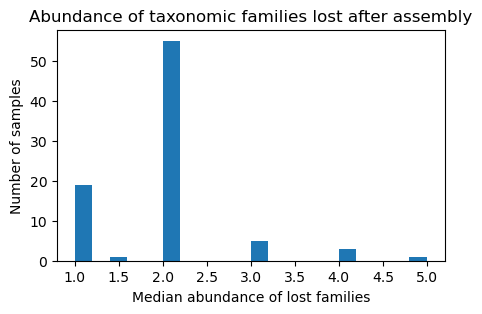

In [57]:
# Plot distribution across all 84 samples
plt.figure(figsize=(5,3))
plt.hist(summary_df["median_lost_abundance"],bins=20)
plt.xlabel("Median abundance of lost families")
plt.ylabel("Number of samples")
plt.title("Abundance of taxonomic families lost after assembly")
plt.show()

#### Interperation:
- The families lost after assembly are consistently low abundance across individual metagenomes.
  - Out of 84 assemblies:
    - 55 had median lost abundance = 2
    - 19 had median lost abundance = 1

In [59]:
summary_df["retained_to_lost_ratio"] = (
    summary_df["median_retained_abundance"] /
    summary_df["median_lost_abundance"]
)
summary_df["retained_to_lost_ratio"].describe()

count      84.000000
mean      147.649206
std       384.178966
min         2.500000
25%         9.125000
50%        20.000000
75%        63.062500
max      2810.500000
Name: retained_to_lost_ratio, dtype: float64

#### Interperation:
- Median ratio = 20, median abundance of retained families was ~20-fold higher than the median abundance of families lost after assembly.

In [50]:
# Distribution of abundance of ALL lost families
all_lost_abundance = []

for sample in samples:
    summary, lost, comparison = compare_sample(sample)
    lost = lost.copy()
    lost["sample"] = sample
    all_lost_abundance.append(lost)
lost_all = pd.concat(all_lost_abundance)

lost_all.shape
lost_all.head(500)
# 42,689 cases where a family was detected in trim but absent in inflate.

,trim,inflate,retention,sample
family,,,,
f__CAG-917,196.0,0.0,0.0,DRR014782
f__Tissierellaceae,144.0,0.0,0.0,DRR014782
f__Emcibacteraceae,93.0,0.0,0.0,DRR014782
f__Bianqueaceae,81.0,0.0,0.0,DRR014782
f__JAAVYR01,72.0,0.0,0.0,DRR014782
...,...,...,...,...
f__Dongiaceae,1.0,0.0,0.0,DRR014785
f__Desulfurobacteriaceae,1.0,0.0,0.0,DRR014785
f__Desulfobulbaceae,1.0,0.0,0.0,DRR014785


In [51]:
lost_all[lost_all["trim"]==381]

,trim,inflate,retention,sample
family,,,,
f__CAG-239,381.0,0.0,0.0,ERR1414265
f__Intestinicryptomonadaceae,381.0,0.0,0.0,ERR2241845


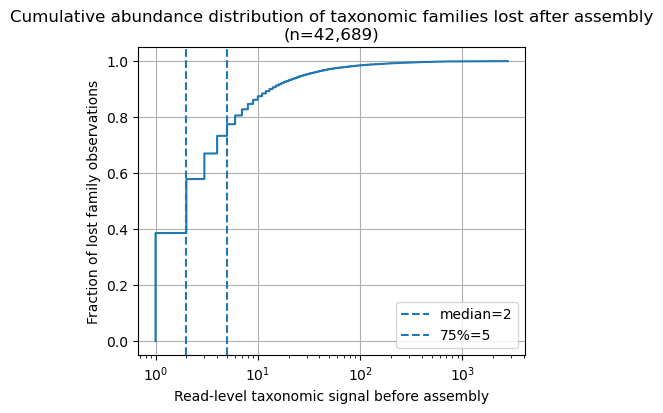

In [52]:
# CDF (cumulative distribution function) of the abundance of families that were lost after assembly.
# Ask - When a taxon is lost after assembly, how abundant was it before assembly?
plt.figure(figsize=(5,4))

values = np.sort(lost_all["trim"])
fraction = np.arange(1, len(values)+1) / len(values)

plt.plot(values, fraction)
plt.xscale("log")

median = lost_all["trim"].median()
q75 = lost_all["trim"].quantile(0.75)

plt.axvline(median,linestyle="--",label=f"median={median:.0f}")
plt.axvline(q75,linestyle="--",label=f"75%={q75:.0f}")
plt.xlabel("Read-level taxonomic signal before assembly")

plt.ylabel("Fraction of lost family observations")
plt.title(f"Cumulative abundance distribution of taxonomic families lost after assembly\n(n={len(values):,})")

plt.legend()
plt.grid()
plt.show()

#### X-axis 
- Read-level abundance ("n_unique_weighted_found") of families that were not recovered a/f assembly.
- Example:
    x = 1 → family had 1 unit of taxonomic signal before assembly
    x = 10 → family had 10 units
    x = 100 → family had 100 units
#### Y-axis, Cumulative fraction of lost families
- number of lost families with abundance ≤ X / total number of lost families
- e.g.: 60% of lost families had abundance ≤2; 75% of lost family had abundance <=5
- Dashed lines show: median = 2, Meaning: Half of all families lost after assembly had read-level taxonomic signal ≤ 2.
- 75% = 5, Meaning: Three quarters of all lost families had read-level taxonomic signal ≤ 5.

#### Figure:
- Across 84 assemblies, 42,689 family-level taxa detected before assembly were absent from assembled genomes
- Lost taxa were overwhelmingly low abundance: the median lost family had only 2 read-level assignments, and 75% had ≤5.
- Although most lost families were low abundance, a small number of higher-abundance families (e.g.: 381) were not recovered, suggesting assembly loss is strongly abundance-dependent but not exclusively limited to rare taxa.

#### Ask - What fraction of the total taxonomic signal (abundance) was lost after assembly?

In [53]:
# Create a pooled comparison dataframe
all_comparisons = []

for sample in samples:
    summary, lost, comparison = compare_sample(sample)  
    comparison = comparison.copy()
    comparison["sample"] = sample    
    all_comparisons.append(comparison)

comparison_all = pd.concat(all_comparisons)
# comparison_all.shape # (64877, 4)
comparison_all.head(500)

,trim,inflate,retention,sample
family,,,,
f__Muribaculaceae,2302293.0,2312425.0,1.004401,DRR014782
f__Bacteroidaceae,1002774.0,1004794.0,1.002014,DRR014782
f__Lachnospiraceae,778807.0,552910.0,0.709945,DRR014782
f__UBA932,380152.0,377319.0,0.992548,DRR014782
f__Oscillospiraceae,233012.0,119156.0,0.511373,DRR014782
...,...,...,...,...
f__UBA1234,5.0,0.0,0.000000,DRR014785
f__GRL18,5.0,0.0,0.000000,DRR014785
f__Verrucomicrobiaceae,5.0,0.0,0.000000,DRR014785


In [54]:
# Calculate total taxonomic signal lost
lost_signal_fraction = (comparison_all["trim"].sum() - comparison_all["inflate"].sum()) / comparison_all["trim"].sum()
lost_signal_fraction

np.float64(0.10596385315178933)

In [55]:
# Also calculate retention
retention = (comparison_all["inflate"].sum()/comparison_all["trim"].sum())
retention
# Assembly retained 89% of family-level taxonomic signal and lost 11%.

np.float64(0.8940361468482106)

#### It is about abundance-weighted recovery, not about number of families:
- Meaning: ~10.6%  of total taxonomic signal lost after assembly, (trim signal−inflate signal)/trim signal
- and 89.5% retained, inflate signal/trim signal
#### conclusion: Assembly preferentially removes rare taxa while preserving most of the overall taxonomic signal.

In [63]:
# compare lost vs retained
lost_all["status"] = "Lost"

retained_all = []
for sample in samples:
    summary, lost, comparison = compare_sample(sample)
    retained = comparison[comparison["inflate"] > 0].copy()
    retained["status"] = "Retained"
    retained_all.append(retained)

retained_all = pd.concat(retained_all)

In [64]:
trim_files = sorted(TRIM_DIR.glob("*.gather.with-lineages.csv"))

print("Number of samples:",len(trim_files))

family_results = []
sample_results = []

for trim_file in trim_files:

    sample = (trim_file.name.replace(".gather.with-lineages.csv",""))
    inflate_file = (INFLATE_DIR /trim_file.name)

    if not inflate_file.exists():
        print("Missing:",sample)
        continue
    print(sample)

    trim = load_family_counts(trim_file)
    inflate = load_family_counts(inflate_file)

    combined = pd.concat([trim.rename("trim"),inflate.rename("inflate")],axis=1).fillna(0)
    combined["retention"] = (combined["inflate"]/combined["trim"])
    
    trim_total = (combined["trim"].sum())
    inflate_total = (combined["inflate"].sum())
    
    combined["trim_relative"] = (combined["trim"]/trim_total)
    combined["inflate_relative"] = (combined["inflate"]/inflate_total)

    combined["relative_shift"] = (combined["inflate_relative"] - combined["trim_relative"])

    combined = (combined.reset_index().rename(columns={"index":"family"}))
    combined.insert(0,"sample",sample)

    family_results.append(combined)

    sample_results.append({
            "sample":sample,
            "trim_signal":trim_total,
            "inflate_signal":inflate_total,
            "retention":inflate_total / trim_total,
            "trim_families":(combined.trim > 0).sum(),
            "inflate_families":(combined.inflate > 0).sum(),
            "families_lost":((combined.trim > 0) & (combined.inflate == 0)).sum()
        })

Number of samples: 84
DRR014782
DRR014785
DRR121397
DRR121401
ERR10695318
ERR1414265
ERR1414271
ERR1869526
ERR1869527
ERR1877479
ERR1877482
ERR2094168
ERR2094174
ERR2094175
ERR2114805
ERR2135457
ERR2200468
ERR2241845
ERR2607414
ERR2607491
ERR2683635
ERR2683639
ERR2750365
ERR2848508
ERR2889251
ERR3155587
ERR3155596
ERR3155597
ERR3273281
ERR3890099
ERR4398707
ERR575692
ERR5866866
ERR5866883
ERR5954451
ERR738544
ERR738545
ERR738546
ERR9456921
SRR1023996
SRR1024014
SRR10527384
SRR10810037
SRR11267050
SRR11267079
SRR12456173
SRR12479795
SRR12480094
SRR12908323
SRR12908327
SRR15604576
SRR1702229
SRR17255031
SRR17257160
SRR1873849
SRR1916815
SRR19759452
SRR2107175
SRR2107179
SRR2753158
SRR3183878
SRR3211795
SRR3719568
SRR3961740
SRR4069403
SRR4305336
SRR490744
SRR5248299
SRR5438753
SRR5574507
SRR5808811
SRR5808830
SRR5924454
SRR6323523
SRR6490004
SRR6490006
SRR6714105
SRR6765262
SRR7299214
SRR7610133
SRR9109404
SRR9182859
SRR9182862
SRR975540


In [65]:
# combine results
family_df = pd.concat(family_results,ignore_index=True)
sample_df = pd.DataFrame(sample_results)

family_df.head()

,sample,family,trim,inflate,retention,trim_relative,inflate_relative,relative_shift
0,DRR014782,f__Muribaculaceae,2302293.0,2312425.0,1.004401,0.426902,0.473854,0.046952
1,DRR014782,f__Bacteroidaceae,1002774.0,1004794.0,1.002014,0.185939,0.205899,0.019960
2,DRR014782,f__Lachnospiraceae,778807.0,552910.0,0.709945,0.144410,0.113300,-0.031110
3,DRR014782,f__UBA932,380152.0,377319.0,0.992548,0.070490,0.077319,0.006829
4,DRR014782,f__Oscillospiraceae,233012.0,119156.0,0.511373,0.043206,0.024417,-0.018789


In [66]:
sample_df.head()

,sample,trim_signal,inflate_signal,retention,trim_families,inflate_families,families_lost
0,DRR014782,5393026.0,4880041.0,0.904880,367,96,275
1,DRR014785,5932250.0,5306172.0,0.894462,375,86,291
2,DRR121397,283449.0,125786.0,0.443769,937,374,578
3,DRR121401,177732.0,68717.0,0.386633,934,348,604
4,ERR10695318,13795612.0,13742947.0,0.996182,362,81,287


In [67]:
# save output
family_df.to_csv(
    OUT_DIR /
    "family_retention_by_sample.csv",
    index=False
)

sample_df.to_csv(
    OUT_DIR /
    "assembly_taxonomic_retention_by_sample.csv",
    index=False
)

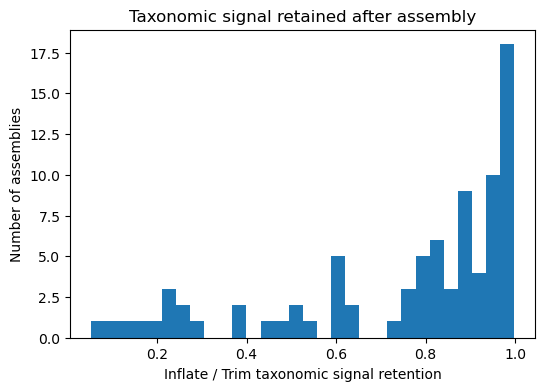

In [68]:
# 1st plot - Does assembly reduce taxonomic signal?
plt.figure(figsize=(6,4))

plt.hist(sample_df["retention"],bins=30)
plt.xlabel("Inflate / Trim taxonomic signal retention")
plt.ylabel("Number of assemblies")
plt.title("Taxonomic signal retained after assembly")

plt.show()

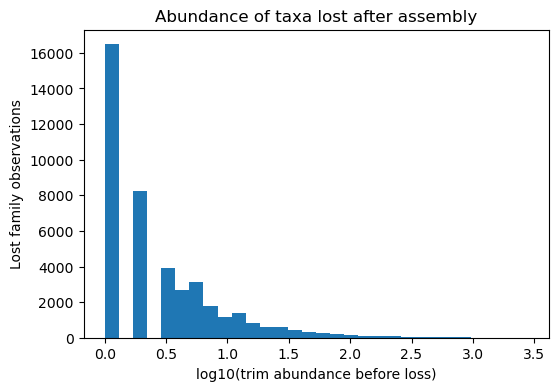

In [69]:
# Are lost taxa low abundance?
lost = family_df[
    (family_df.trim > 0)
    &
    (family_df.inflate == 0)
]


plt.figure(figsize=(6,4))

plt.hist(np.log10(lost["trim"]),bins=30)
plt.xlabel("log10(trim abundance before loss)")
plt.ylabel("Lost family observations")

plt.title("Abundance of taxa lost after assembly")

plt.show()

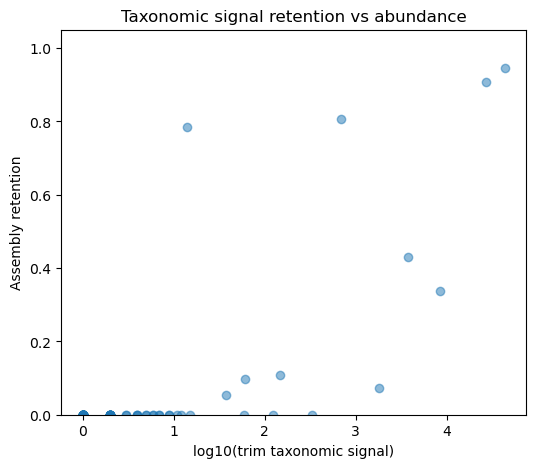

In [70]:
# retention vs abundance for all families:
import matplotlib.pyplot as plt

plot_df = comparison[comparison["trim"] > 0].copy()

plt.figure(figsize=(6,5))
plt.scatter(np.log10(plot_df["trim"]),plot_df["retention"],alpha=0.5)

plt.xlabel("log10(trim taxonomic signal)")
plt.ylabel("Assembly retention")
plt.title("Taxonomic signal retention vs abundance")
plt.ylim(0,1.05)

plt.show()

In [71]:
plot_df["abundance_bin"] = pd.cut(
    plot_df["trim"],
    bins=[1,10,100,1000,10000,100000,1000000]
)

plot_df.groupby("abundance_bin")["retention"].median()

/tmp/ipykernel_2853269/555837329.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df.groupby("abundance_bin")["retention"].median()


abundance_bin
(1, 10]              0.000000
(10, 100]            0.000000
(100, 1000]          0.054422
(1000, 10000]        0.338480
(10000, 100000]      0.927575
(100000, 1000000]         NaN
Name: retention, dtype: float64

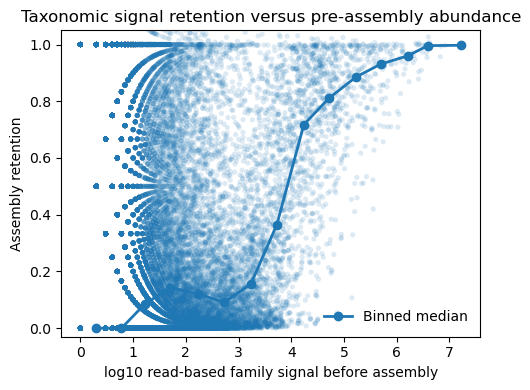

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plot_df = comparison_all.loc[
    comparison_all["trim"] > 0,
    ["trim", "retention"]
].dropna().copy()

plot_df["log10_trim"] = np.log10(plot_df["trim"])

# Divide observations into abundance bins
plot_df["abundance_bin"] = pd.cut(
    plot_df["log10_trim"],
    bins=np.arange(
        np.floor(plot_df["log10_trim"].min()),
        np.ceil(plot_df["log10_trim"].max()) + 0.5,
        0.5
    )
)

binned = (
    plot_df.groupby("abundance_bin", observed=True)
    .agg(
        median_retention=("retention", "median"),
        n=("retention", "size"),
        x=("log10_trim", "median")
    )
    .reset_index()
)

plt.figure(figsize=(5, 4))

plt.scatter(
    plot_df["log10_trim"],
    plot_df["retention"],
    s=14,
    alpha=0.15,
    edgecolors="none"
)

plt.plot(
    binned["x"],
    binned["median_retention"],
    marker="o",
    linewidth=2,
    label="Binned median"
)

plt.xlabel("log10 read-based family signal before assembly")
plt.ylabel("Assembly retention")
plt.title("Taxonomic signal retention versus pre-assembly abundance")
plt.ylim(-0.03, 1.05)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

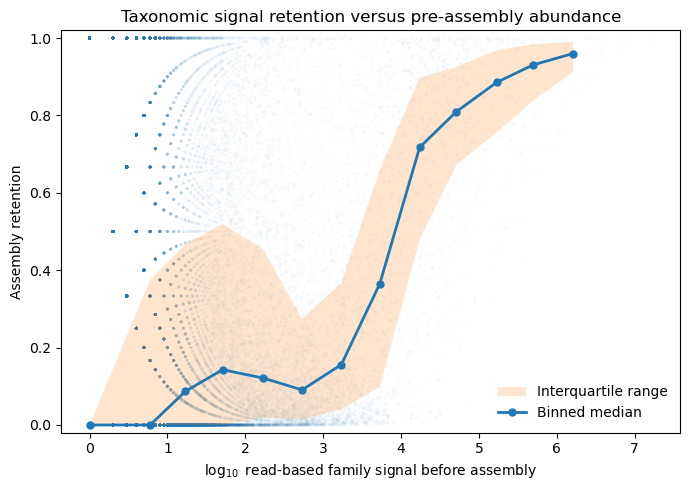

In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plot_df = comparison_all.loc[
    comparison_all["trim"] > 0,
    ["trim", "retention"]
].dropna().copy()

plot_df["log10_trim"] = np.log10(plot_df["trim"])

# Equal-width bins on the log10 scale
bin_edges = np.arange(
    np.floor(plot_df["log10_trim"].min()),
    np.ceil(plot_df["log10_trim"].max()) + 0.5,
    0.5
)

plot_df["abundance_bin"] = pd.cut(
    plot_df["log10_trim"],
    bins=bin_edges,
    include_lowest=True
)

binned = (
    plot_df.groupby("abundance_bin", observed=True)
    .agg(
        x=("log10_trim", "median"),
        median=("retention", "median"),
        q25=("retention", lambda x: x.quantile(0.25)),
        q75=("retention", lambda x: x.quantile(0.75)),
        n=("retention", "size")
    )
    .reset_index()
)

# Avoid presenting unstable bins with very few observations
binned = binned[binned["n"] >= 20]

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    plot_df["log10_trim"],
    plot_df["retention"],
    s=5,
    alpha=0.025,
    edgecolors="none",
    rasterized=True
)

ax.fill_between(
    binned["x"],
    binned["q25"],
    binned["q75"],
    alpha=0.2,
    label="Interquartile range"
)

ax.plot(
    binned["x"],
    binned["median"],
    marker="o",
    markersize=5,
    linewidth=2,
    label="Binned median"
)

ax.set_xlabel(r"$\log_{10}$ read-based family signal before assembly")
ax.set_ylabel("Assembly retention")
ax.set_title("Taxonomic signal retention versus pre-assembly abundance")
ax.set_ylim(-0.02, 1.02)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [31]:
# For each sample calculate: taxonomic signal retention= ∑trim/∑inflate
comparison["inflate"].sum() / comparison["trim"].sum()
	

np.float64(0.7534735829177527)